In [55]:
#Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [56]:
df_Belgium = df[df['job_country'] == 'Belgium']

In [57]:
df_skills = df_Belgium.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
20,Data Scientist,r
20,Data Scientist,python
20,Data Scientist,sql
20,Data Scientist,pandas
20,Data Scientist,numpy
...,...,...
785518,Data Engineer at Proton Therapy Leader,airflow
785518,Data Engineer at Proton Therapy Leader,terraform
785518,Data Engineer at Proton Therapy Leader,gitlab
785518,Data Engineer at Proton Therapy Leader,kubernetes


In [58]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count

job_skills  job_title_short          
airflow     Business Analyst               2
            Cloud Engineer                10
            Data Analyst                  15
            Data Engineer                269
            Data Scientist                35
                                        ... 
zoom        Data Analyst                   6
            Data Engineer                 13
            Data Scientist                 1
            Machine Learning Engineer      1
            Software Engineer              1
Length: 1184, dtype: int64

In [59]:
type(df_skills_count)

pandas.Series

In [60]:
df_skills_count = df_skills_count.reset_index(name='skill_count')


In [61]:
df_skills_count


,job_skills,job_title_short,skill_count
0,airflow,Business Analyst,2
1,airflow,Cloud Engineer,10
2,airflow,Data Analyst,15
3,airflow,Data Engineer,269
4,airflow,Data Scientist,35
...,...,...,...
1179,zoom,Data Analyst,6
1180,zoom,Data Engineer,13
1181,zoom,Data Scientist,1
1182,zoom,Machine Learning Engineer,1


In [62]:
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count


,job_skills,job_title_short,skill_count
756,python,Data Engineer,1762
969,sql,Data Engineer,1702
968,sql,Data Analyst,1519
68,azure,Data Engineer,1319
757,python,Data Scientist,1106
...,...,...,...
6,airflow,Senior Data Analyst,1
1157,wire,Business Analyst,1
23,angular,Machine Learning Engineer,1
19,angular,Cloud Engineer,1


In [69]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles


['Data Analyst', 'Data Engineer', 'Data Scientist']

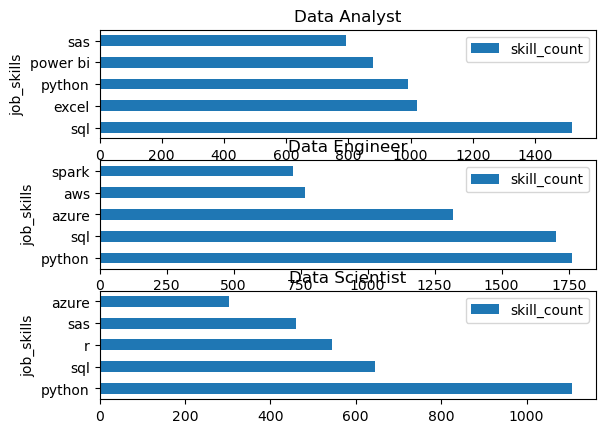

In [70]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', ax=ax[i], title=job_title)

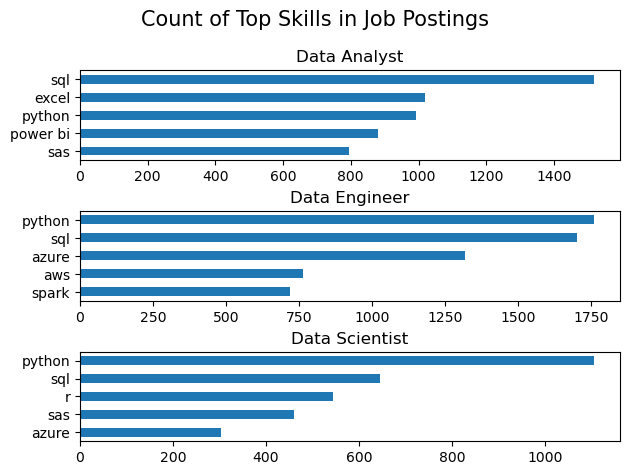

In [72]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Count of Top Skills in Job Postings', fontsize=15)
fig.tight_layout(h_pad=.5)
plt.show()

In [75]:
df_job_title_count = df_Belgium['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,3807
1,Data Engineer,3273
2,Data Scientist,1996
3,Business Analyst,1109
4,Software Engineer,662
5,Senior Data Engineer,325
6,Senior Data Scientist,269
7,Cloud Engineer,219
8,Machine Learning Engineer,214
9,Senior Data Analyst,204


In [76]:
pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

,job_skills,job_title_short,skill_count,jobs_total
0,python,Data Engineer,1762,3273
1,sql,Data Engineer,1702,3273
2,sql,Data Analyst,1519,3807
3,azure,Data Engineer,1319,3273
4,python,Data Scientist,1106,1996
...,...,...,...,...
1179,airflow,Senior Data Analyst,1,204
1180,wire,Business Analyst,1,1109
1181,angular,Machine Learning Engineer,1,214
1182,angular,Cloud Engineer,1,219


In [78]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count'] / df_skills_perc['jobs_total']

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Engineer,1762,3273,53.834403
1,sql,Data Engineer,1702,3273,52.001222
2,sql,Data Analyst,1519,3807,39.900184
3,azure,Data Engineer,1319,3273,40.299419
4,python,Data Scientist,1106,1996,55.410822
...,...,...,...,...,...
1179,airflow,Senior Data Analyst,1,204,0.490196
1180,wire,Business Analyst,1,1109,0.090171
1181,angular,Machine Learning Engineer,1,214,0.467290
1182,angular,Cloud Engineer,1,219,0.456621


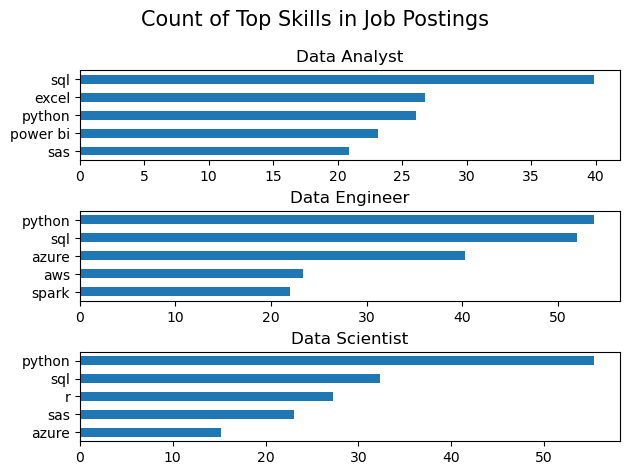

In [81]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Count of Top Skills in Job Postings', fontsize=15)
fig.tight_layout(h_pad=.5)
plt.show()

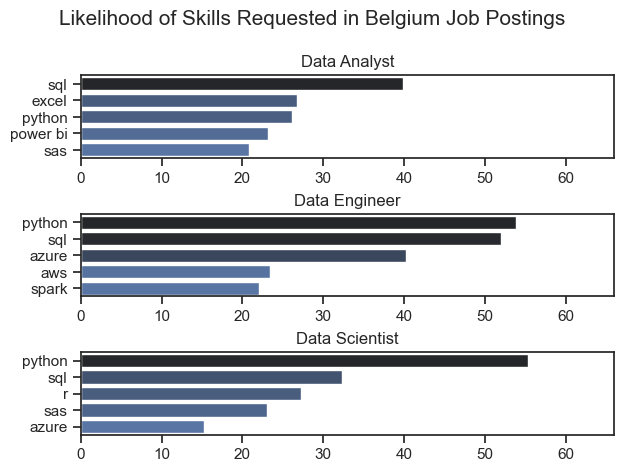

In [86]:
import seaborn as sns
fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,66)

fig.suptitle('Likelihood of Skills Requested in Belgium Job Postings', fontsize=15)
fig.tight_layout(h_pad=.5)
plt.show()

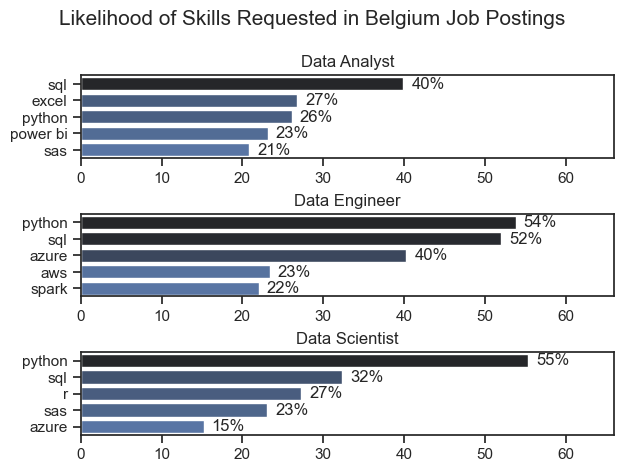

In [93]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,66)

    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center') #we provide x-y values of intersection, then what we want to make appear (v is percent value)


fig.suptitle('Likelihood of Skills Requested in Belgium Job Postings', fontsize=15)
fig.tight_layout(h_pad=.5)
plt.show()

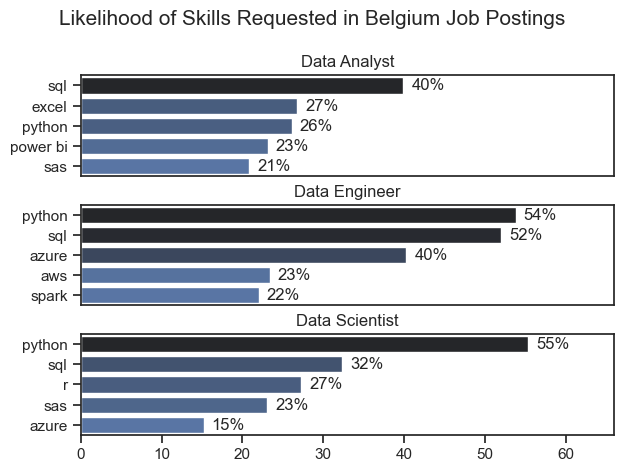

In [94]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,66)

    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center') #we provide x-y values of intersection, then what we want to make appear (v is percent value)
    
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])


fig.suptitle('Likelihood of Skills Requested in Belgium Job Postings', fontsize=15)
fig.tight_layout(h_pad=.5)
plt.show()